Using synthetic test data.

Generating test cone-beam projections...
Generating projection 1 / 8
Generating projection 2 / 8
Generating projection 3 / 8
Generating projection 4 / 8
Generating projection 5 / 8
Generating projection 6 / 8
Generating projection 7 / 8
Generating projection 8 / 8

Starting ART reconstruction...
Volume shape: (16, 16, 16)
Number of views: 8

ART Iteration 1 of 3
  View 1 / 8 completed
  View 2 / 8 completed
  View 3 / 8 completed
  View 4 / 8 completed
  View 5 / 8 completed
  View 6 / 8 completed
  View 7 / 8 completed
  View 8 / 8 completed
Iteration 1 completed

ART Iteration 2 of 3
  View 1 / 8 completed
  View 2 / 8 completed
  View 3 / 8 completed
  View 4 / 8 completed
  View 5 / 8 completed
  View 6 / 8 completed
  View 7 / 8 completed
  View 8 / 8 completed
Iteration 2 completed

ART Iteration 3 of 3
  View 1 / 8 completed
  View 2 / 8 completed
  View 3 / 8 completed
  View 4 / 8 completed
  View 5 / 8 completed
  View 6 / 8 completed
  View 7 / 8 

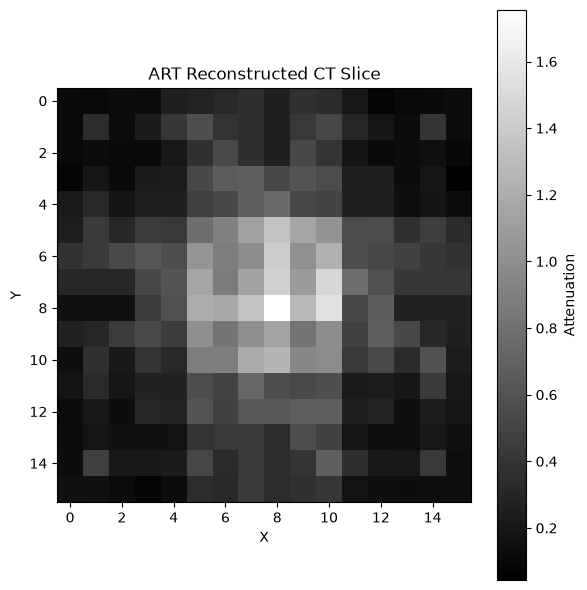


Reconstruction completed.
Saved as: ART_reconstructed_volume.npy


In [6]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. TRILINEAR INTERPOLATION
# ============================================================

def trilinear_interpolation(volume, x, y, z):
    """
    Get the volume value at a non-integer (x, y, z) position
    using trilinear interpolation.
    """

    nz, ny, nx = volume.shape

    # If point is outside the volume
    if x < 0 or x > nx - 1:
        return 0.0

    if y < 0 or y > ny - 1:
        return 0.0

    if z < 0 or z > nz - 1:
        return 0.0

    x0 = int(np.floor(x))
    x1 = min(x0 + 1, nx - 1)

    y0 = int(np.floor(y))
    y1 = min(y0 + 1, ny - 1)

    z0 = int(np.floor(z))
    z1 = min(z0 + 1, nz - 1)

    xd = x - x0
    yd = y - y0
    zd = z - z0

    c000 = volume[z0, y0, x0]
    c100 = volume[z0, y0, x1]
    c010 = volume[z0, y1, x0]
    c110 = volume[z0, y1, x1]

    c001 = volume[z1, y0, x0]
    c101 = volume[z1, y0, x1]
    c011 = volume[z1, y1, x0]
    c111 = volume[z1, y1, x1]

    c00 = c000 * (1 - xd) + c100 * xd
    c01 = c001 * (1 - xd) + c101 * xd
    c10 = c010 * (1 - xd) + c110 * xd
    c11 = c011 * (1 - xd) + c111 * xd

    c0 = c00 * (1 - yd) + c10 * yd
    c1 = c01 * (1 - yd) + c11 * yd

    value = c0 * (1 - zd) + c1 * zd

    return value


# ============================================================
# 2. CREATE VOLUME COORDINATES
# ============================================================

def create_volume_coordinates(nx, ny, nz,
                              voxel_x, voxel_y, voxel_z):

    x = (np.arange(nx) - (nx - 1) / 2) * voxel_x
    y = (np.arange(ny) - (ny - 1) / 2) * voxel_y
    z = (np.arange(nz) - (nz - 1) / 2) * voxel_z

    return x, y, z


# ============================================================
# 3. X-RAY SOURCE POSITION
# ============================================================

def source_position(angle, sod):
    """
    Calculate X-ray source position for circular gantry rotation.
    """

    sx = sod * np.cos(angle)
    sy = sod * np.sin(angle)
    sz = 0.0

    return np.array([sx, sy, sz])


# ============================================================
# 4. DETECTOR BASIS VECTORS
# ============================================================

def detector_basis(angle):
    """
    Calculate detector horizontal and vertical directions.
    """

    # Horizontal detector direction
    u = np.array([
        -np.sin(angle),
        np.cos(angle),
        0.0
    ])

    # Vertical detector direction
    v = np.array([
        0.0,
        0.0,
        1.0
    ])

    return u, v


# ============================================================
# 5. DETECTOR PIXEL POSITION
# ============================================================

def detector_pixel_position(source,
                            angle,
                            row,
                            col,
                            detector_rows,
                            detector_cols,
                            sdd,
                            pixel_u,
                            pixel_v):

    u, v = detector_basis(angle)

    # Detector center is opposite to X-ray source
    detector_center = -source * (sdd / np.linalg.norm(source))

    u_position = (
        (col - (detector_cols - 1) / 2)
        * pixel_u
    )

    v_position = (
        (row - (detector_rows - 1) / 2)
        * pixel_v
    )

    detector_point = (
        detector_center
        + u_position * u
        + v_position * v
    )

    return detector_point


# ============================================================
# 6. RAY-BOX INTERSECTION
# ============================================================

def ray_box_intersection(source,
                         direction,
                         xmin, xmax,
                         ymin, ymax,
                         zmin, zmax):

    t_min = -np.inf
    t_max = np.inf

    # X direction
    if abs(direction[0]) < 1e-12:

        if source[0] < xmin or source[0] > xmax:
            return None

    else:

        t1 = (xmin - source[0]) / direction[0]
        t2 = (xmax - source[0]) / direction[0]

        t_near = min(t1, t2)
        t_far = max(t1, t2)

        t_min = max(t_min, t_near)
        t_max = min(t_max, t_far)

    # Y direction
    if abs(direction[1]) < 1e-12:

        if source[1] < ymin or source[1] > ymax:
            return None

    else:

        t1 = (ymin - source[1]) / direction[1]
        t2 = (ymax - source[1]) / direction[1]

        t_near = min(t1, t2)
        t_far = max(t1, t2)

        t_min = max(t_min, t_near)
        t_max = min(t_max, t_far)

    # Z direction
    if abs(direction[2]) < 1e-12:

        if source[2] < zmin or source[2] > zmax:
            return None

    else:

        t1 = (zmin - source[2]) / direction[2]
        t2 = (zmax - source[2]) / direction[2]

        t_near = min(t1, t2)
        t_far = max(t1, t2)

        t_min = max(t_min, t_near)
        t_max = min(t_max, t_far)

    # No intersection
    if t_max <= t_min:
        return None

    # Ray must move forward
    if t_max <= 0:
        return None

    t_min = max(t_min, 0.0)

    return t_min, t_max


# ============================================================
# 7. CONE-BEAM FORWARD PROJECTION
# ============================================================

def cone_beam_forward_project(volume,
                              angle,
                              sod,
                              sdd,
                              detector_rows,
                              detector_cols,
                              detector_pixel_u,
                              detector_pixel_v,
                              voxel_x,
                              voxel_y,
                              voxel_z):

    nz, ny, nx = volume.shape

    # Volume physical limits
    x_size = nx * voxel_x
    y_size = ny * voxel_y
    z_size = nz * voxel_z

    xmin = -x_size / 2
    xmax = x_size / 2

    ymin = -y_size / 2
    ymax = y_size / 2

    zmin = -z_size / 2
    zmax = z_size / 2

    projection = np.zeros(
        (detector_rows, detector_cols),
        dtype=np.float64
    )

    source = source_position(angle, sod)

    # Loop through detector pixels
    for row in range(detector_rows):

        for col in range(detector_cols):

            detector_point = detector_pixel_position(
                source,
                angle,
                row,
                col,
                detector_rows,
                detector_cols,
                sdd,
                detector_pixel_u,
                detector_pixel_v
            )

            # Ray from source to detector
            ray = detector_point - source

            ray_length = np.linalg.norm(ray)

            if ray_length == 0:
                continue

            direction = ray / ray_length

            # Find intersection with volume
            intersection = ray_box_intersection(
                source,
                direction,
                xmin, xmax,
                ymin, ymax,
                zmin, zmax
            )

            if intersection is None:
                continue

            t_start, t_end = intersection

            # Sampling distance
            step = min(
                voxel_x,
                voxel_y,
                voxel_z
            )

            number_of_samples = int(
                np.ceil((t_end - t_start) / step)
            )

            if number_of_samples <= 0:
                continue

            total = 0.0

            for n in range(number_of_samples):

                t = t_start + (
                    n + 0.5
                ) * (t_end - t_start) / number_of_samples

                point = source + t * direction

                # Convert physical position
                # to voxel coordinates
                ix = (
                    point[0] / voxel_x
                    + (nx - 1) / 2
                )

                iy = (
                    point[1] / voxel_y
                    + (ny - 1) / 2
                )

                iz = (
                    point[2] / voxel_z
                    + (nz - 1) / 2
                )

                value = trilinear_interpolation(
                    volume,
                    ix,
                    iy,
                    iz
                )

                total += value

            # Approximate line integral
            projection[row, col] = (
                total *
                (t_end - t_start) /
                number_of_samples
            )

    return projection


# ============================================================
# 8. ART BACKPROJECTION / RAY UPDATE
# ============================================================

def art_ray_update(volume,
                   error,
                   angle,
                   sod,
                   sdd,
                   detector_rows,
                   detector_cols,
                   detector_pixel_u,
                   detector_pixel_v,
                   voxel_x,
                   voxel_y,
                   voxel_z,
                   relaxation):

    """
    ART update.

    One detector ray is selected.
    Its projection error is calculated.
    The error is distributed to the voxels
    crossed by that ray.
    """

    nz, ny, nx = volume.shape

    x_size = nx * voxel_x
    y_size = ny * voxel_y
    z_size = nz * voxel_z

    xmin = -x_size / 2
    xmax = x_size / 2

    ymin = -y_size / 2
    ymax = y_size / 2

    zmin = -z_size / 2
    zmax = z_size / 2

    source = source_position(angle, sod)

    # --------------------------------------------------------
    # Choose the detector ray
    # --------------------------------------------------------

    detector_point = detector_pixel_position(
        source,
        angle,
        error["row"],
        error["col"],
        detector_rows,
        detector_cols,
        sdd,
        detector_pixel_u,
        detector_pixel_v
    )

    ray = detector_point - source

    ray_length = np.linalg.norm(ray)

    if ray_length == 0:
        return

    direction = ray / ray_length

    # --------------------------------------------------------
    # Find where ray enters/exits volume
    # --------------------------------------------------------

    intersection = ray_box_intersection(
        source,
        direction,
        xmin, xmax,
        ymin, ymax,
        zmin, zmax
    )

    if intersection is None:
        return

    t_start, t_end = intersection

    step = min(
        voxel_x,
        voxel_y,
        voxel_z
    )

    number_of_samples = int(
        np.ceil((t_end - t_start) / step)
    )

    if number_of_samples <= 0:
        return

    # --------------------------------------------------------
    # First calculate ray normalization
    #
    # ART:
    #
    # x_new =
    # x_old +
    # lambda * error * a / ||a||^2
    # --------------------------------------------------------

    weight_sum = 0.0

    for n in range(number_of_samples):

        t = t_start + (
            n + 0.5
        ) * (t_end - t_start) / number_of_samples

        point = source + t * direction

        ix = (
            point[0] / voxel_x
            + (nx - 1) / 2
        )

        iy = (
            point[1] / voxel_y
            + (ny - 1) / 2
        )

        iz = (
            point[2] / voxel_z
            + (nz - 1) / 2
        )

        if (
            ix < 0 or ix > nx - 1 or
            iy < 0 or iy > ny - 1 or
            iz < 0 or iz > nz - 1
        ):
            continue

        # For this educational ART implementation,
        # each ray sample gets approximately equal weight.
        weight = (
            (t_end - t_start)
            / number_of_samples
        )

        weight_sum += weight * weight

    if weight_sum == 0:
        return

    # --------------------------------------------------------
    # ART correction
    # --------------------------------------------------------

    correction_factor = (
        relaxation *
        error["value"] /
        weight_sum
    )

    for n in range(number_of_samples):

        t = t_start + (
            n + 0.5
        ) * (t_end - t_start) / number_of_samples

        point = source + t * direction

        ix = (
            point[0] / voxel_x
            + (nx - 1) / 2
        )

        iy = (
            point[1] / voxel_y
            + (ny - 1) / 2
        )

        iz = (
            point[2] / voxel_z
            + (nz - 1) / 2
        )

        ix_round = int(round(ix))
        iy_round = int(round(iy))
        iz_round = int(round(iz))

        if (
            ix_round < 0 or ix_round >= nx or
            iy_round < 0 or iy_round >= ny or
            iz_round < 0 or iz_round >= nz
        ):
            continue

        weight = (
            (t_end - t_start)
            / number_of_samples
        )

        volume[
            iz_round,
            iy_round,
            ix_round
        ] += correction_factor * weight

    # CT attenuation cannot normally be negative
    volume[volume < 0] = 0


# ============================================================
# 9. ART RECONSTRUCTION
# ============================================================

def ART_reconstruction(
        measured_projections,
        angles,
        volume_shape,
        sod,
        sdd,
        detector_pixel_u,
        detector_pixel_v,
        voxel_x,
        voxel_y,
        voxel_z,
        iterations,
        relaxation):

    """
    Main ART reconstruction.

    For every iteration:
        1. Select a projection view
        2. Select detector ray
        3. Forward project that ray
        4. Calculate error
        5. Update voxels crossed by that ray
    """

    number_of_views = len(angles)

    detector_rows = measured_projections.shape[1]
    detector_cols = measured_projections.shape[2]

    nz, ny, nx = volume_shape

    # --------------------------------------------------------
    # Initial reconstruction
    # --------------------------------------------------------

    volume = np.zeros(
        (nz, ny, nx),
        dtype=np.float64
    )

    print("\nStarting ART reconstruction...")
    print("Volume shape:", volume.shape)
    print("Number of views:", number_of_views)

    # --------------------------------------------------------
    # Iterations
    # --------------------------------------------------------

    for iteration in range(iterations):

        print(
            "\nART Iteration",
            iteration + 1,
            "of",
            iterations
        )

        # ----------------------------------------------------
        # Loop through every projection view
        # ----------------------------------------------------

        for view in range(number_of_views):

            angle = angles[view]

            measured = measured_projections[view]

            # ------------------------------------------------
            # IMPORTANT:
            #
            # ART processes individual rays.
            #
            # Here we loop through detector pixels.
            # ------------------------------------------------

            for row in range(detector_rows):

                for col in range(detector_cols):

                    # ----------------------------------------
                    # Calculate estimated value for this ray
                    # ----------------------------------------

                    single_ray_projection = (
                        cone_beam_forward_project(
                            volume,
                            angle,
                            sod,
                            sdd,
                            detector_rows,
                            detector_cols,
                            detector_pixel_u,
                            detector_pixel_v,
                            voxel_x,
                            voxel_y,
                            voxel_z
                        )
                    )

                    estimated = (
                        single_ray_projection[row, col]
                    )

                    # ----------------------------------------
                    # Measured value
                    # ----------------------------------------

                    measured_value = measured[row, col]

                    # ----------------------------------------
                    # ART error
                    # ----------------------------------------

                    ray_error = (
                        measured_value -
                        estimated
                    )

                    # ----------------------------------------
                    # Store ray information
                    # ----------------------------------------

                    error = {
                        "row": row,
                        "col": col,
                        "value": ray_error
                    }

                    # ----------------------------------------
                    # ART update
                    # ----------------------------------------

                    art_ray_update(
                        volume,
                        error,
                        angle,
                        sod,
                        sdd,
                        detector_rows,
                        detector_cols,
                        detector_pixel_u,
                        detector_pixel_v,
                        voxel_x,
                        voxel_y,
                        voxel_z,
                        relaxation
                    )

            print(
                "  View",
                view + 1,
                "/",
                number_of_views,
                "completed"
            )

        print(
            "Iteration",
            iteration + 1,
            "completed"
        )

    return volume


# ============================================================
# 10. CREATE A SIMPLE 3D TEST PHANTOM
# ============================================================

def create_test_phantom(nx, ny, nz):

    phantom = np.zeros(
        (nz, ny, nx),
        dtype=np.float64
    )

    # Physical coordinate system
    z, y, x = np.mgrid[
        -1:1:complex(nz),
        -1:1:complex(ny),
        -1:1:complex(nx)
    ]

    # --------------------------------------------------------
    # Main ellipsoid
    # --------------------------------------------------------

    main_object = (
        (x / 0.65) ** 2 +
        (y / 0.75) ** 2 +
        (z / 0.65) ** 2
        <= 1
    )

    phantom[main_object] = 1.0

    # --------------------------------------------------------
    # Smaller object
    # --------------------------------------------------------

    small_object = (
        ((x - 0.30) / 0.20) ** 2 +
        ((y + 0.20) / 0.25) ** 2 +
        (z / 0.30) ** 2
        <= 1
    )

    phantom[small_object] = 1.5

    return phantom


# ============================================================
# 11. MAIN PROGRAM
# ============================================================

if __name__ == "__main__":

    # ========================================================
    # SELECT INPUT MODE
    # ========================================================

    USE_TEST_DATA = True


    # ========================================================
    # TEST DATA
    # ========================================================

    if USE_TEST_DATA:

        print("Using synthetic test data.")

        # Small volume because scratch ART is computationally
        # expensive.

        Nx = 16
        Ny = 16
        Nz = 16

        number_of_views = 8

        detector_rows = 16
        detector_cols = 16

        # Create phantom
        original_volume = create_test_phantom(
            Nx,
            Ny,
            Nz
        )

        # Gantry angles
        angles = np.linspace(
            0,
            2 * np.pi,
            number_of_views,
            endpoint=False
        )

        # CT geometry
        SOD = 400.0
        SDD = 600.0

        DETECTOR_PIXEL_U = 1.0
        DETECTOR_PIXEL_V = 1.0

        VOXEL_SIZE_X = 1.0
        VOXEL_SIZE_Y = 1.0
        VOXEL_SIZE_Z = 1.0

        # ----------------------------------------------------
        # Generate projection data
        # ----------------------------------------------------

        measured_projections = np.zeros(
            (
                number_of_views,
                detector_rows,
                detector_cols
            ),
            dtype=np.float64
        )

        print("\nGenerating test cone-beam projections...")

        for view in range(number_of_views):

            print(
                "Generating projection",
                view + 1,
                "/",
                number_of_views
            )

            measured_projections[view] = (
                cone_beam_forward_project(
                    original_volume,
                    angles[view],
                    SOD,
                    SDD,
                    detector_rows,
                    detector_cols,
                    DETECTOR_PIXEL_U,
                    DETECTOR_PIXEL_V,
                    VOXEL_SIZE_X,
                    VOXEL_SIZE_Y,
                    VOXEL_SIZE_Z
                )
            )


    # ========================================================
    # REAL DATA
    # ========================================================

    else:

        print("Using real CT projection data.")

        # ----------------------------------------------------
        # Load measured projection data
        #
        # Expected shape:
        #
        # (total_views,
        #  detector_rows,
        #  detector_channels)
        # ----------------------------------------------------

        measured_projections = np.load(
            "sinogram.npy"
        )

        # ----------------------------------------------------
        # Load gantry angles
        # ----------------------------------------------------

        angles = np.load(
            "angles.npy"
        )

        # ----------------------------------------------------
        # Load CT configuration
        # ----------------------------------------------------

        import json

        with open(
            "ct_config.json",
            "r"
        ) as file:

            ct_config = json.load(file)

        # ----------------------------------------------------
        # Get detector dimensions automatically
        # ----------------------------------------------------

        number_of_views = (
            measured_projections.shape[0]
        )

        detector_rows = (
            measured_projections.shape[1]
        )

        detector_cols = (
            measured_projections.shape[2]
        )

        # ----------------------------------------------------
        # Read geometry parameters
        #
        # These names are examples.
        # Change them according to your real CT config.
        # ----------------------------------------------------

        SOD = ct_config["SOD"]

        SDD = ct_config["SDD"]

        DETECTOR_PIXEL_U = (
            ct_config["detector_pixel_u"]
        )

        DETECTOR_PIXEL_V = (
            ct_config["detector_pixel_v"]
        )

        VOXEL_SIZE_X = (
            ct_config["voxel_size_x"]
        )

        VOXEL_SIZE_Y = (
            ct_config["voxel_size_y"]
        )

        VOXEL_SIZE_Z = (
            ct_config["voxel_size_z"]
        )

        Nx = ct_config["volume_x"]

        Ny = ct_config["volume_y"]

        Nz = ct_config["volume_z"]


        # ----------------------------------------------------
        # IMPORTANT
        #
        # If angles are given in degrees:
        #
        # angles = np.deg2rad(angles)
        #
        # If already in radians, do not convert.
        # ----------------------------------------------------


        original_volume = None


    # ========================================================
    # ART PARAMETERS
    # ========================================================

    ITERATIONS = 3

    RELAXATION = 0.05


    # ========================================================
    # RUN ART
    # ========================================================

    reconstructed_volume = ART_reconstruction(
        measured_projections,
        angles,
        (Nz, Ny, Nx),
        SOD,
        SDD,
        DETECTOR_PIXEL_U,
        DETECTOR_PIXEL_V,
        VOXEL_SIZE_X,
        VOXEL_SIZE_Y,
        VOXEL_SIZE_Z,
        ITERATIONS,
        RELAXATION
    )


    # ========================================================
    # DISPLAY CENTRAL AXIAL SLICE
    # ========================================================

    middle_slice = Nz // 2

    plt.figure(figsize=(6, 6))

    plt.imshow(
        reconstructed_volume[middle_slice],
        cmap="gray"
    )

    plt.title(
        "ART Reconstructed CT Slice"
    )

    plt.xlabel("X")
    plt.ylabel("Y")

    plt.colorbar(
        label="Attenuation"
    )

    plt.tight_layout()

    plt.show()


    # ========================================================
    # SAVE RECONSTRUCTED VOLUME
    # ========================================================

    np.save(
        "ART_reconstructed_volume.npy",
        reconstructed_volume
    )

    print(
        "\nReconstruction completed."
    )

    print(
        "Saved as: ART_reconstructed_volume.npy"
    )